In [149]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [151]:
df=pd.read_csv('Player.csv')

In [153]:
df.head(5)

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


In [155]:
df.shape

(322, 21)

In [157]:
df.info

<bound method DataFrame.info of             Unnamed: 0  AtBat  Hits  HmRun  Runs  RBI  Walks  Years  CAtBat  \
0       -Andy Allanson    293    66      1    30   29     14      1     293   
1          -Alan Ashby    315    81      7    24   38     39     14    3449   
2         -Alvin Davis    479   130     18    66   72     76      3    1624   
3        -Andre Dawson    496   141     20    65   78     37     11    5628   
4    -Andres Galarraga    321    87     10    39   42     30      2     396   
..                 ...    ...   ...    ...   ...  ...    ...    ...     ...   
317      -Willie McGee    497   127      7    65   48     37      5    2703   
318   -Willie Randolph    492   136      5    76   50     94     12    5511   
319    -Wayne Tolleson    475   126      3    61   43     52      6    1700   
320     -Willie Upshaw    573   144      9    85   60     78      8    3198   
321     -Willie Wilson    631   170      9    77   44     31     11    4908   

     CHits  ...  CR

In [159]:
df.isnull().sum()

Unnamed: 0     0
AtBat          0
Hits           0
HmRun          0
Runs           0
RBI            0
Walks          0
Years          0
CAtBat         0
CHits          0
CHmRun         0
CRuns          0
CRBI           0
CWalks         0
League         0
Division       0
PutOuts        0
Assists        0
Errors         0
Salary        59
NewLeague      0
dtype: int64

In [163]:
df.duplicated().sum()

0

In [165]:
df.dropna(inplace=True)

In [169]:
df.drop(df.columns[0],axis=1,inplace=True)

In [171]:
df.head(5)

,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


In [173]:
df.isnull().sum()

Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64

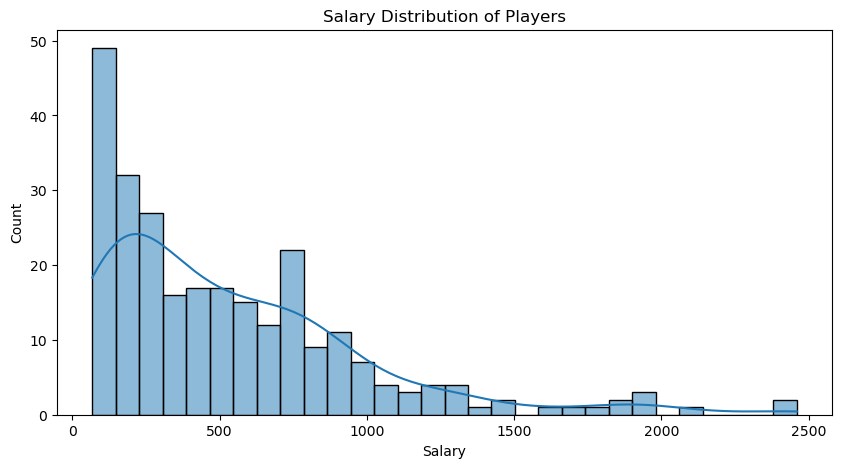

In [177]:
plt.figure(figsize=(10,5))
sns.histplot(df['Salary'],kde=True,bins=30)
plt.title("Salary Distribution of Players")
plt.show()

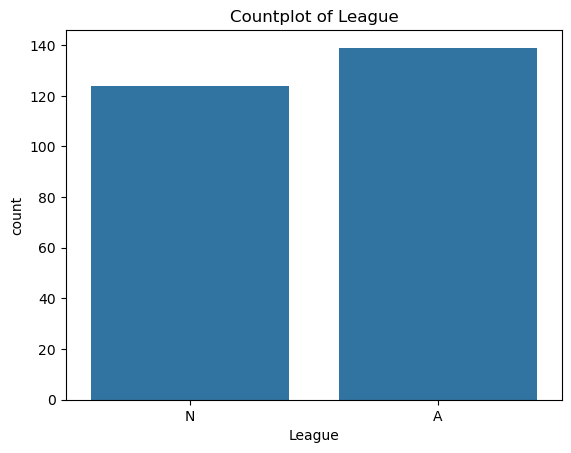

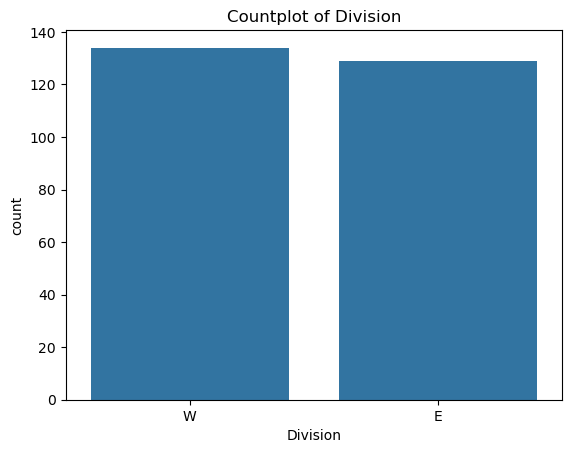

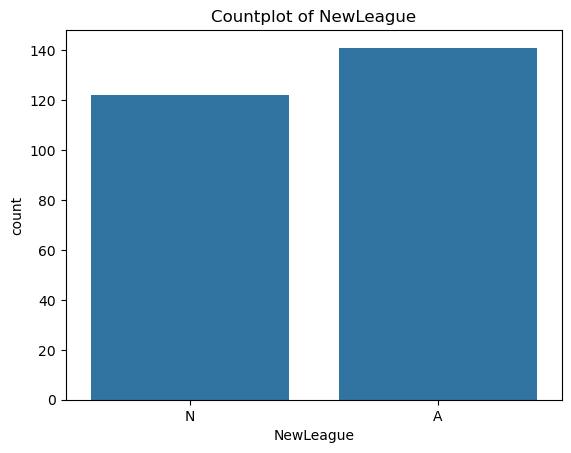

In [178]:
categorical_cols = ['League', 'Division', 'NewLeague']

for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"Countplot of {col}")
    plt.show()


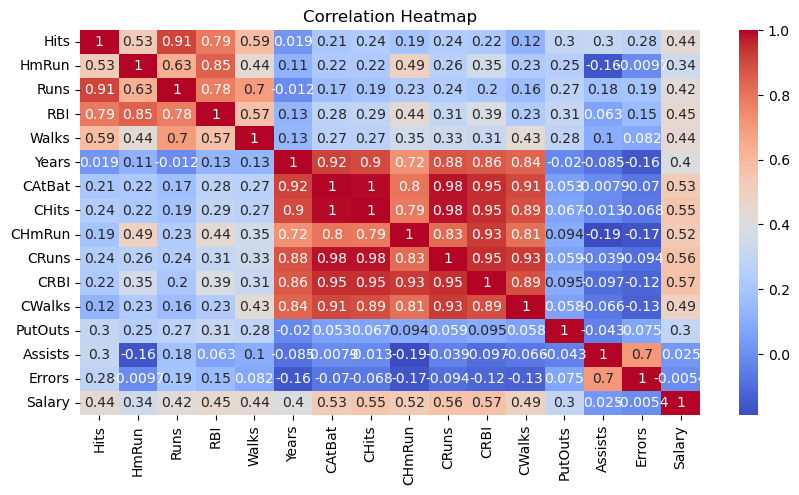

In [180]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

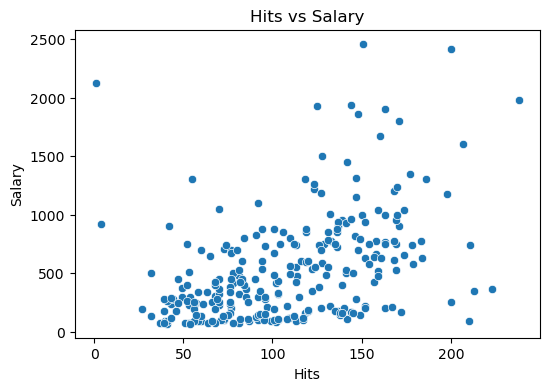

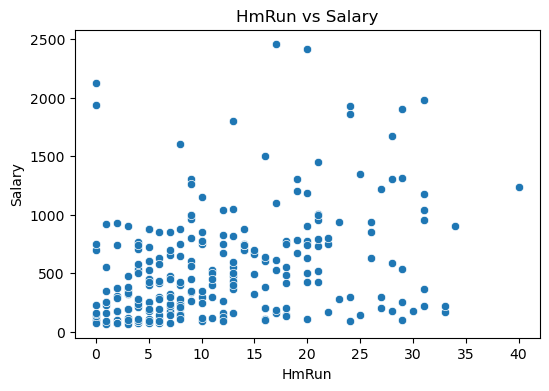

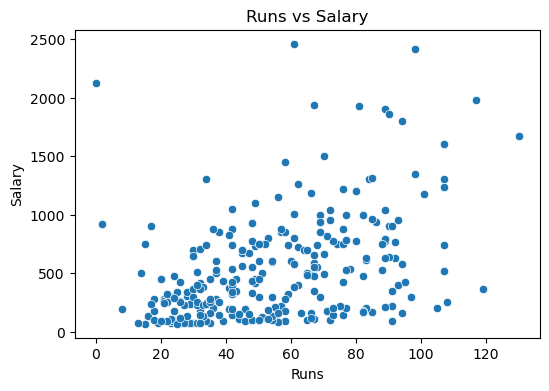

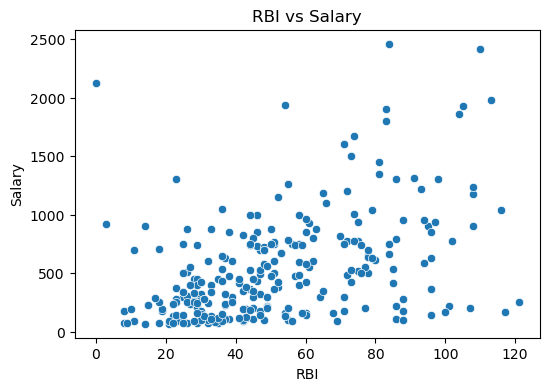

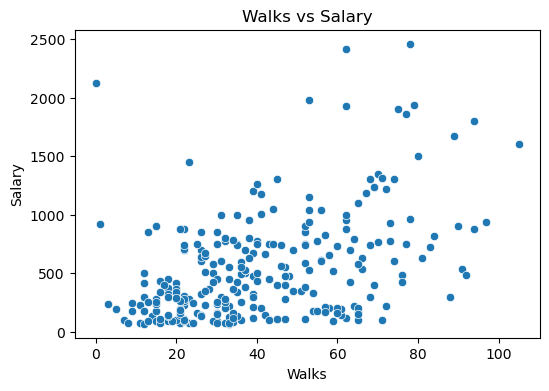

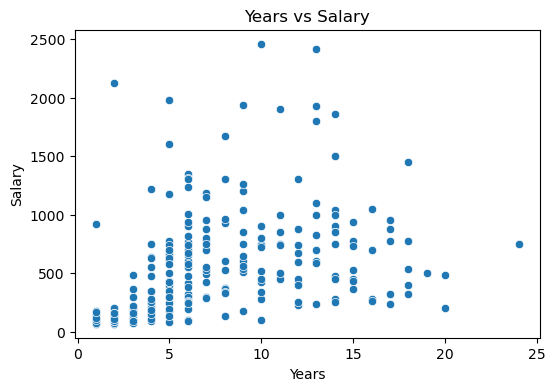

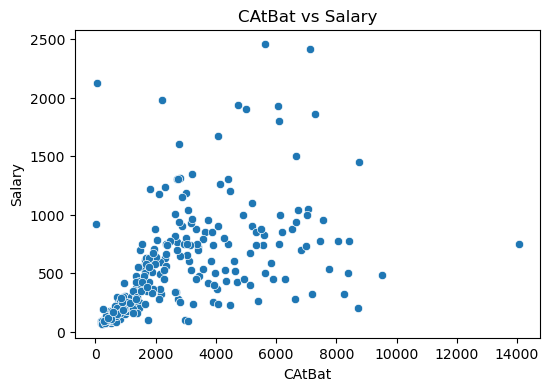

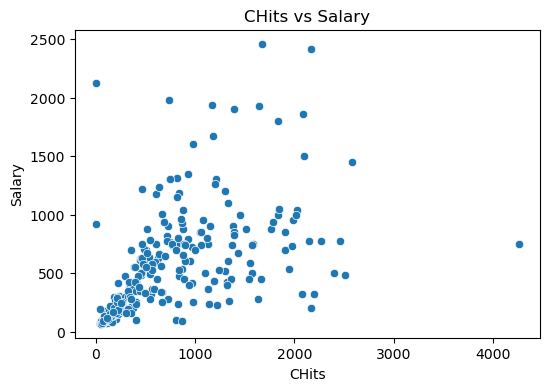

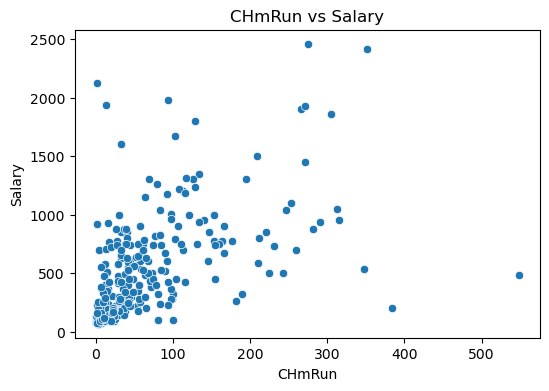

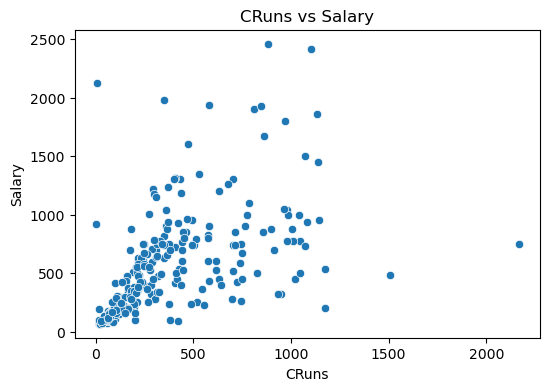

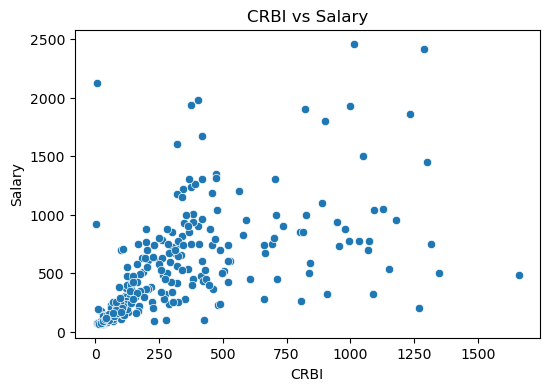

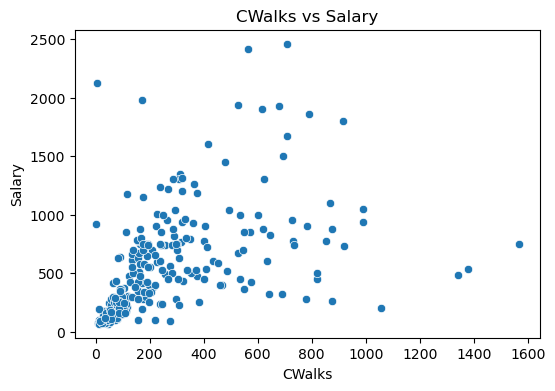

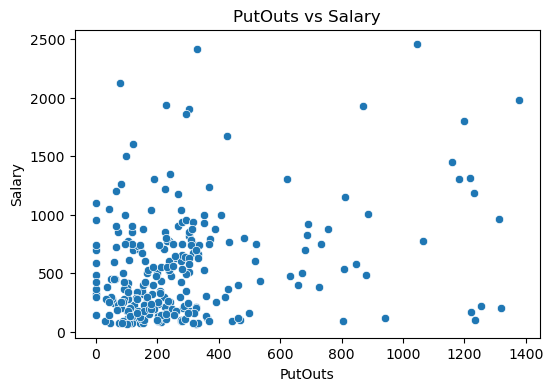

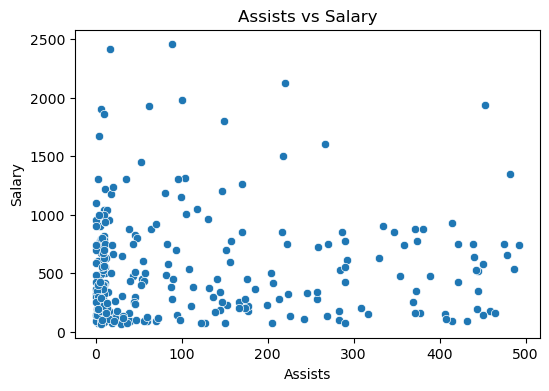

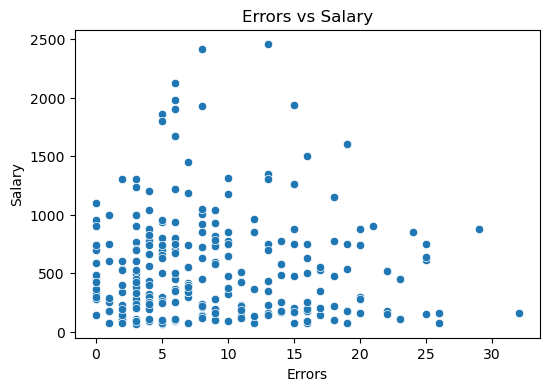

In [181]:
numerical_cols = df.select_dtypes(include='number').drop(columns=['Salary']).columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y='Salary')
    plt.title(f"{col} vs Salary")
    plt.show()


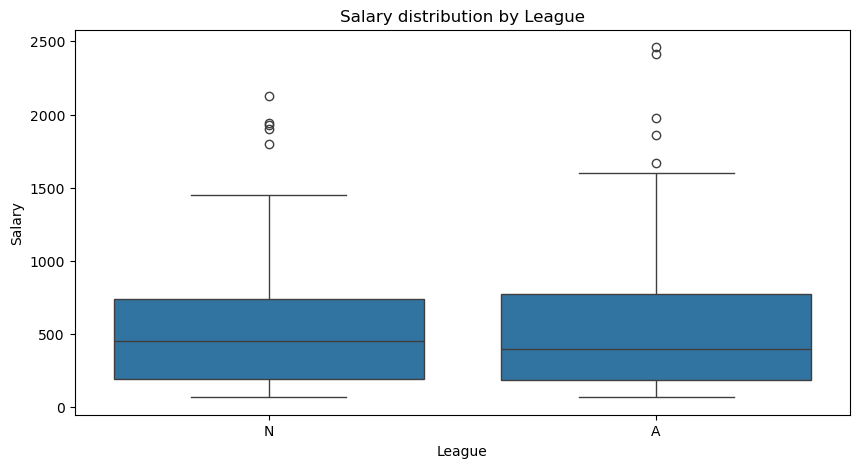

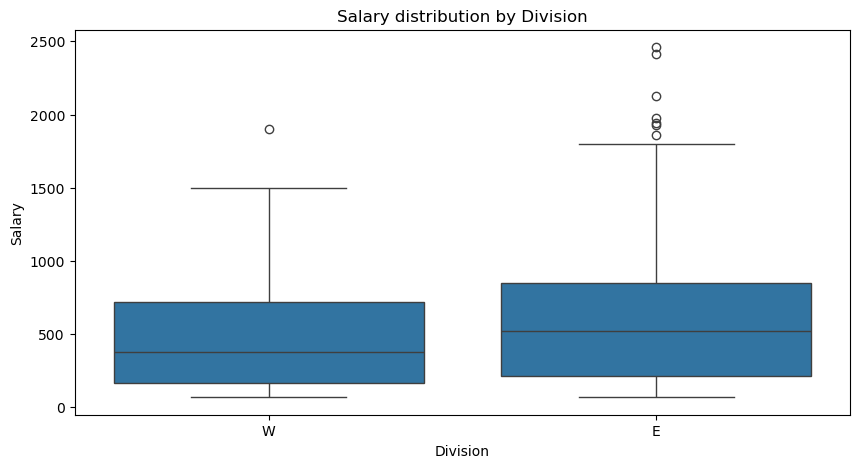

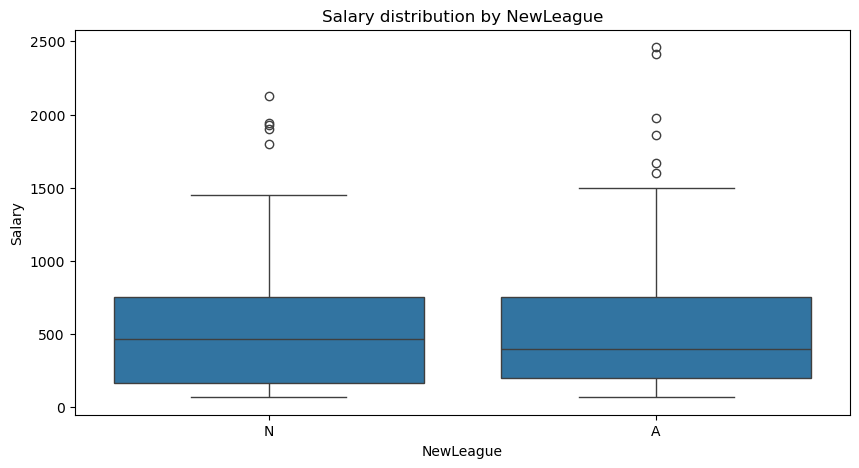

In [183]:
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df,x=col,y='Salary')
    plt.title(f"Salary distribution by {col}")
    plt.show()

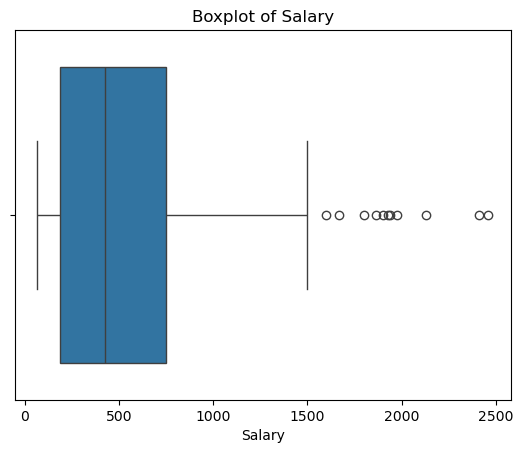

In [184]:
sns.boxplot(x=df['Salary'])
plt.title("Boxplot of Salary")
plt.show()

In [211]:
from sklearn.compose import ColumnTransformer
# One-Hot Encoding for categorical columns
categorical_features = ['League', 'Division', 'NewLeague']
numerical_features = df.columns.difference(categorical_features + ['Salary'])

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),  # Scale numerical features
        ('cat', OneHotEncoder(), categorical_features)  # One-Hot Encode categorical features
    ])
X_transformed = preprocessor.fit_transform(X)

In [197]:
X=df.drop(columns=['Salary'])
y=df['Salary']

In [213]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_transformed,y,test_size=0.2,random_state=42)

In [215]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [217]:
lr.fit(X_train,y_train)

LinearRegression()

In [219]:
y_pred=lr.predict(X_test)

In [221]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 138295.30912776198
Root Mean Squared Error: 371.88077273201685
R^2 Score: 0.23539685664063925


In [223]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

# Print the evaluation metrics
print(f'Random Forest - Mean Squared Error: {mse_rf}')
print(f'Random Forest - Root Mean Squared Error: {rmse_rf}')
print(f'Random Forest - R^2 Score: {r2_rf}')


Random Forest - Mean Squared Error: 92764.970765636
Random Forest - Root Mean Squared Error: 304.5734242602857
Random Forest - R^2 Score: 0.48712368706939724


In [225]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the GradientBoostingRegressor
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = mse_gb ** 0.5
r2_gb = r2_score(y_test, y_pred_gb)

# Print the evaluation metrics
print(f'Gradient Boosting - Mean Squared Error: {mse_gb}')
print(f'Gradient Boosting - Root Mean Squared Error: {rmse_gb}')
print(f'Gradient Boosting - R^2 Score: {r2_gb}')


Gradient Boosting - Mean Squared Error: 88177.97717434913
Gradient Boosting - Root Mean Squared Error: 296.94776842796637
Gradient Boosting - R^2 Score: 0.5124841258332825


In [227]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

grid = GridSearchCV(GradientBoostingRegressor(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV R² Score:", grid.best_score_)


Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best CV R² Score: 0.661666610556669
